# Avaliação dos Resultados

Neste notebook são apresentados os resultados dos experimentos realizados para classificação sons pulmonares.

Inicialmente, são comparados diferentes modelos de redes neurais e diferentes representações dos sinais no formato 2D. Em seguida, são avaliadas estratégias de combinação de features e o impacto do uso de transfer learning.

As comparações são realizadas principalmente por meio das métricas F1 Macro, F1 Micro (ou acurácia) e matrizes de confusão.

In [1]:
import os
import sys
# Add the parent directory to the Python path to allow module imports
sys.path.append(os.path.dirname(os.getcwd()))
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.metrics as skm
import IPython.display as ipd
import seaborn as sns
from pandas.io.formats.style import Styler


def get_classification_report(
    y_true: np.array,
    y_pred: np.array,
    class_names: list,
    selected_metrics: list = ["precision", "recall", "f1-score"]
) -> pd.DataFrame:
    """
    Compute classification report metrics for each class. All y values must be in one-hot format (shape: [n_samples, n_classes]).
    This works both for multilabel and multiclass classification.
    Args:
        y_true (np.array): True labels in one-hot format.
        y_pred (np.array): Predicted labels in one-hot format.
        class_names (list of str): Names of the classes.
        selected_metrics (list of str): List of metrics to include in the DataFrame. Must be a subset of ["precision", "recall", "f1-score"].
    Returns:
        pd.DataFrame: DataFrame with the classification report metrics for each class.
    """
    report = skm.classification_report(
        y_true,
        y_pred,
        labels=list(range(len(class_names))) if len(class_names) > 1 else [1],
        target_names=class_names,
        output_dict=True,
        zero_division=np.nan
    )
    if "accuracy" in report:
        acc_value = report["accuracy"]
        report["accuracy"] = {}
        for selected_metric in selected_metrics:
            report["accuracy"][selected_metric] = acc_value
        report["accuracy"]["support"] = report["macro avg"]["support"]

    # Create a DataFrame from the classification report
    columns = selected_metrics + ["support"]
    df = pd.DataFrame(report).T[columns]
    return df


def compare_classification_reports(reports: list, experiments: list) -> Styler:
    """
    Compare multiple classification reports and highlight the best values for each metric.
    Args:
        reports (list of pd.DataFrame): List of DataFrames with the classification reports.
        experiments (list of str): Names of the experiments.
    Returns:
        Styler: Styler object with the styled DataFrame.
    """
    metrics = reports[0].columns        # Get the metrics columns
    metrics = metrics.drop("support")   # Remove the support column from the metrics
    support_columns = [report["support"] for report in reports]

    # Drop the support column from each report and set the MultiIndex
    for i, report in enumerate(reports):
        report.drop("support", axis=1, inplace=True)
        report.columns = pd.MultiIndex.from_product([[experiments[i]], report.columns])

    combined_report = pd.concat(reports, axis=1)

    formatter = {col: '{:.3f}' for col in combined_report.columns}

    # Mantain the support column if all support columns are equal
    if all(support.equals(support_columns[0]) for support in support_columns):
        combined_report[("", "support")] = support_columns[0]
        formatter[("", "support")] = "{:.0f}"

    # Center align the column headers
    styled_report = combined_report.style.format(formatter, na_rep="")
    styled_report = styled_report.set_table_styles({
        **{(col, metric): [{"selector": "th", "props": [("text-align", "center")]}] for col in experiments for metric in metrics}
    }, overwrite=False)

    return styled_report


def plot_cm(cm: np.array, class_names:list, title:str, ax: plt.Axes = None):
    """
    Plot a confusion matrix using seaborn heatmap.
    Args:
        cm (np.array): Confusion matrix to plot.
        class_names (list of str): Names of the classes.
        title (str): Title of the plot.
        ax (plt.Axes, optional): Axes to plot on. If None, a new figure and axes will be created.
    """
    cm_percent = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    sns.heatmap(cm_percent, annot=True, fmt=".1f", cmap="Blues", xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)
    if ax is None:
        plt.tight_layout()
        plt.show()


def plot_multiple_cms(cms: list, titles: list, class_names: list, super_title: str = None):
    """
    Plot multiple confusion matrices in a grid layout.
    Args:
        cms (list of np.array): List of confusion matrices to plot.
        class_names (list of str): Names of the classes.
        titles (list of str): Titles for each confusion matrix.
        super_title (str, optional): Title for the entire figure.
    """
    n = len(cms)
    cols = min(n, 3)
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
    axes = axes.flatten()
    for i, (cm, title) in enumerate(zip(cms, titles)):
        plot_cm(cm, class_names, title, ax=axes[i])
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")
    if super_title:
        plt.suptitle(super_title, fontsize=16)
    plt.tight_layout()
    plt.show()


def show_results(experiments: dict):
    """
    Show the classification report and confusion matrix for each experiment.
    Args:
        experiments (dict): Dictionary with the experiment name as key and the path to the CSV file as value.
    """
    classification_reports = {}
    confusion_matrices = {}

    for experiment_name, csv_path in experiments.items():
        df = pd.read_csv(csv_path)
        if "target" not in df.columns or "pred" not in df.columns:
            continue
        y_true = df["target"].astype(int).to_numpy()
        y_pred = df["pred"].astype(int).to_numpy()

        class_names = [c.replace("prob_", "") for c in df.columns if c.startswith("prob_")]

        # Get the classification report
        report = get_classification_report(y_true, y_pred, class_names)
        classification_reports[experiment_name] = report

        # Get the confusion matrix
        cm = skm.confusion_matrix(y_true, y_pred, labels=list(range(len(class_names))))
        model_name, feature_name = experiment_name.split(" - ")
        confusion_matrices[model_name, feature_name] = cm

    print(f"{"="*40}\n======== Classification Reports ========\n{"="*40}")
    comparison = compare_classification_reports(list(classification_reports.values()), list(classification_reports.keys()))
    ipd.display(comparison)

    print(f"{"="*40}\n========== Confusion Matrices ==========\n{"="*40}")
    num_models = len(set(model for model, _ in confusion_matrices.keys()))
    if num_models == 1:
        # Plot confusion matrices for the same model with different features
        cms, titles = zip(*[
            (cm, feature) for (model, feature), cm in confusion_matrices.items()
        ])
        model = list(confusion_matrices.keys())[0][0]
        plot_multiple_cms(cms, titles, class_names, super_title=model)
    else:
        # Plot confusion matrices for different models with the same feature
        for feature_name in list(set(feature for _, feature in confusion_matrices.keys())):
            cms, titles = zip(*[
                (cm, model) for (model, feature), cm in confusion_matrices.items()
                if feature == feature_name
            ])
            plot_multiple_cms(cms, titles, class_names, super_title=feature_name)

## Comparação dos Modelos

Aqui, avaliamos diferentes arquiteturas de redes neurais convolucionais utilizando diferentes representações do sinal de áudio.

Foram avaliados os modelos InceptionV3, ResNet50 e DenseNet121, comumente utilizados na literatura, com as seguintes features:

- Magnitude da Transformada de Fourier de Curto Prazo (MagSTFT)
- Fase da STFT (Phase)
- MelSpectrogram
- MFCC
- Delta dos MFCCs (MFCCDelta)
- Chromagrama

O objetivo é identificar quais combinações de modelo e feature apresentam melhor desempenho.

======== Classification Reports ========


========== Confusion Matrices ==========


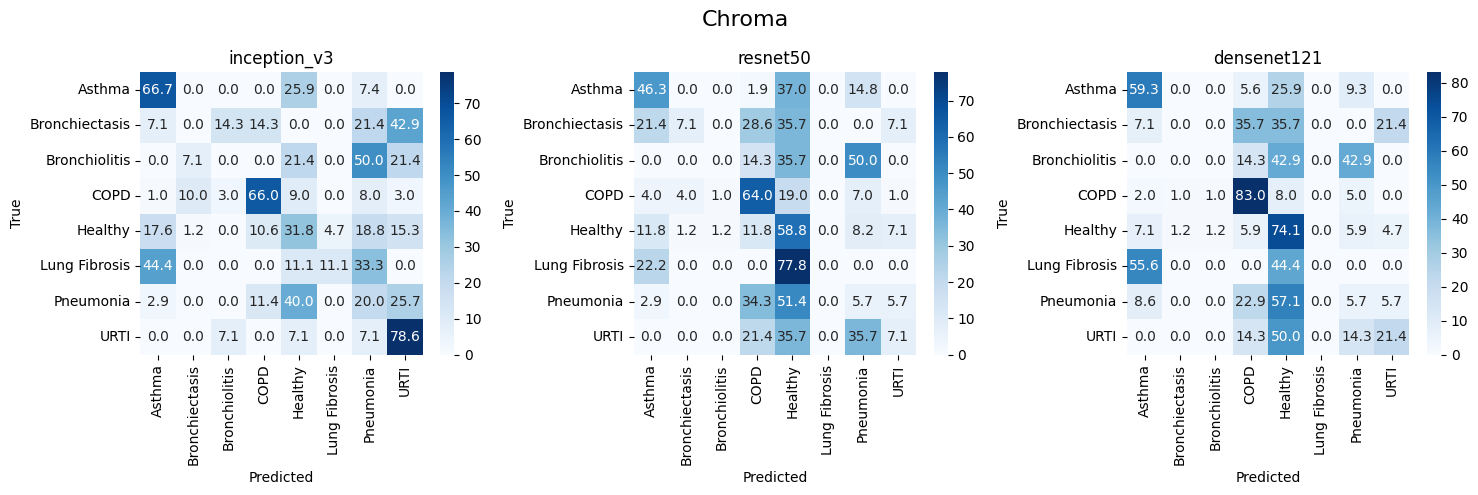

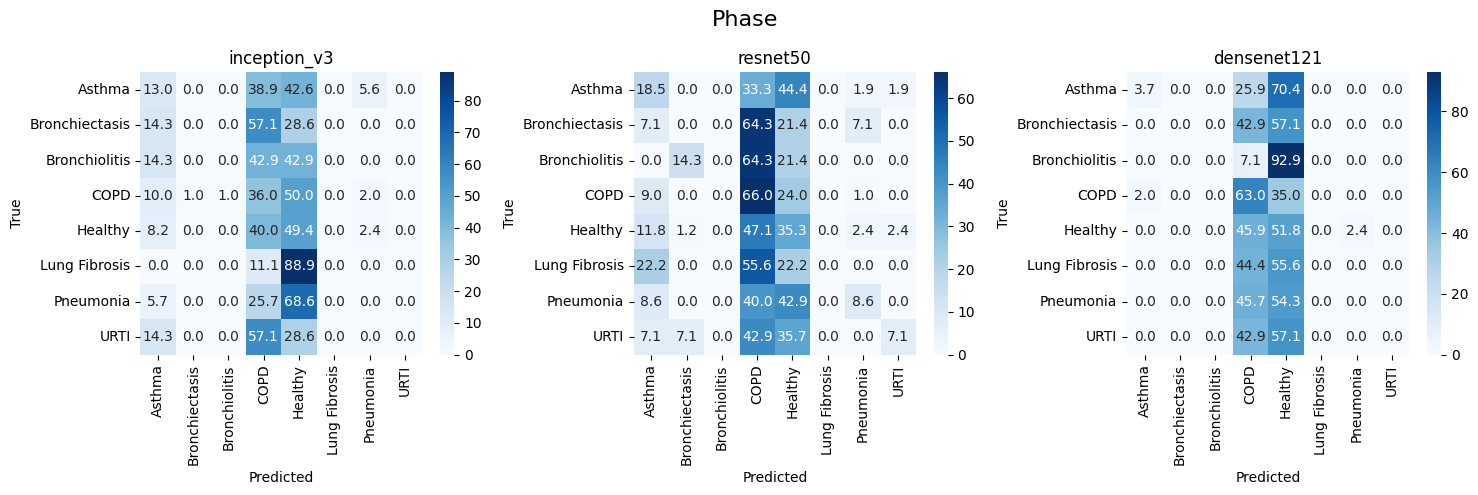

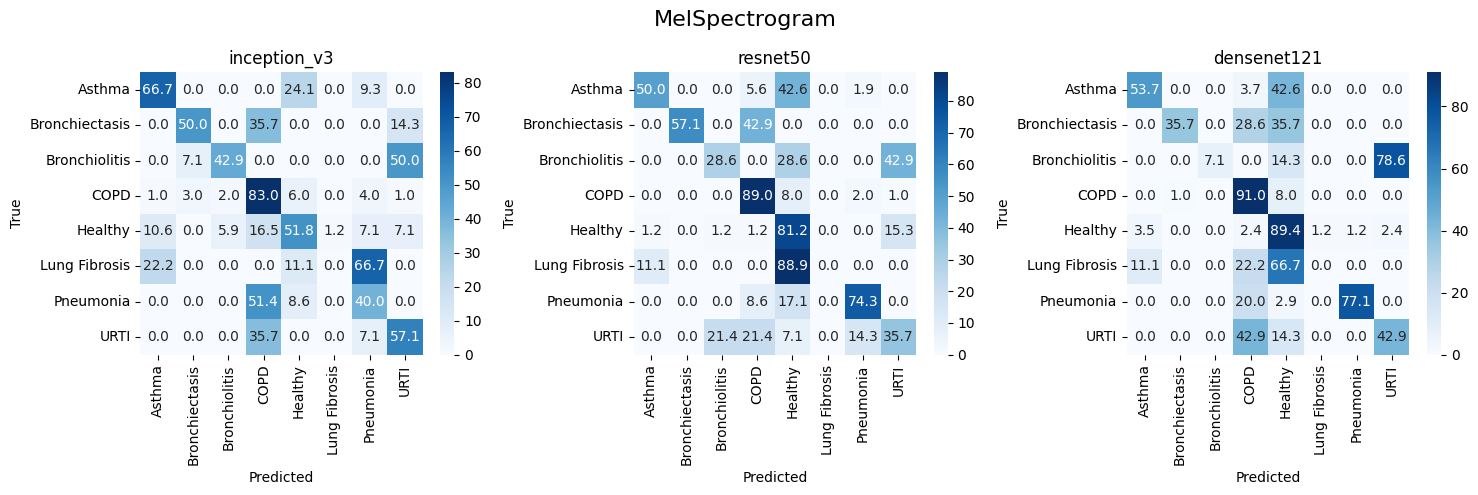

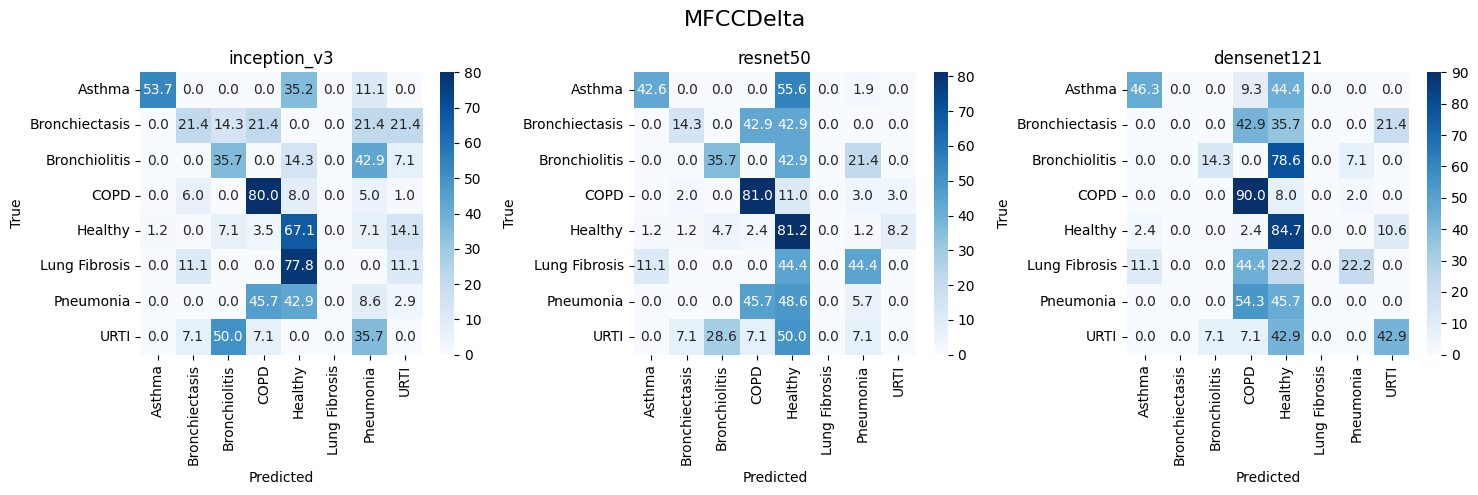

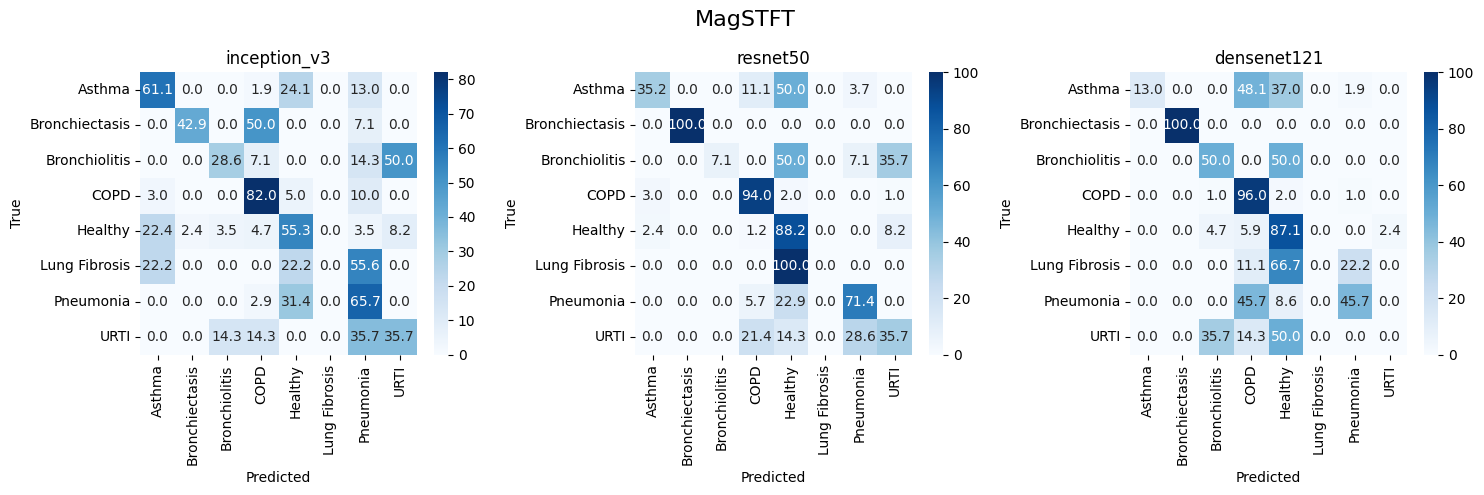

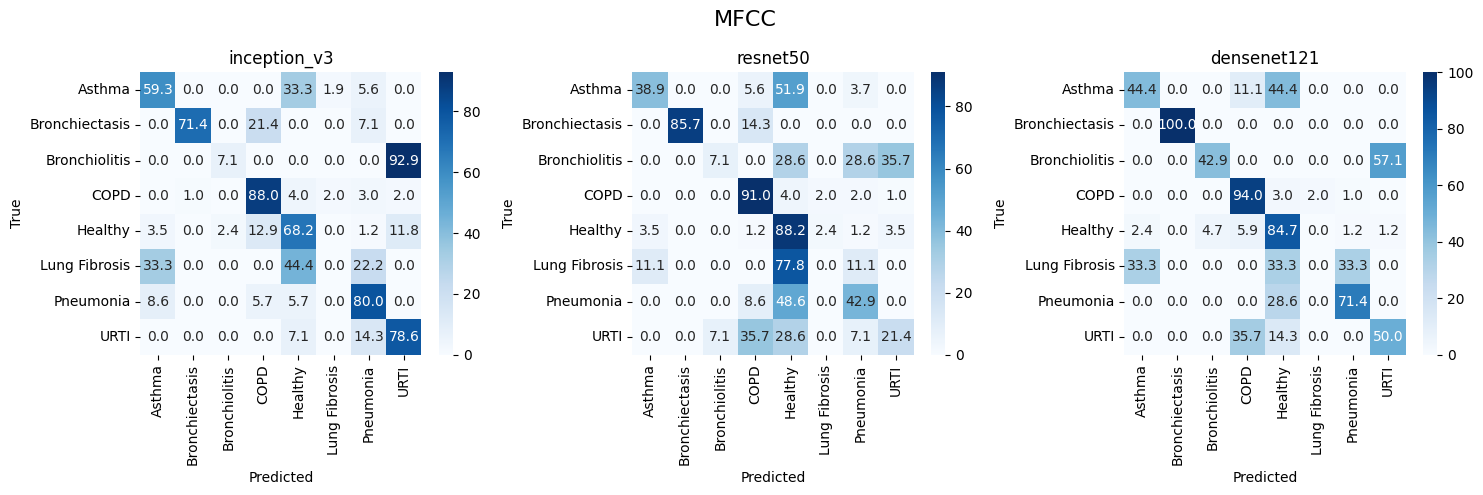

In [2]:
experiments = {
    "inception_v3 - MagSTFT": "../results/inception_v3-classes=8-equalizer-sample_limit=1000-MagSTFT_results.csv",
    "inception_v3 - Phase": "../results/inception_v3-classes=8-equalizer-sample_limit=1000-Phase_results.csv",
    "inception_v3 - MelSpectrogram": "../results/inception_v3-classes=8-equalizer-sample_limit=1000-MelSpectrogram_results.csv",
    "inception_v3 - MFCC": "../results/inception_v3-classes=8-equalizer-sample_limit=1000-MFCC_results.csv",
    "inception_v3 - MFCCDelta": "../results/inception_v3-classes=8-equalizer-sample_limit=1000-MFCCDelta_results.csv",
    "inception_v3 - Chroma": "../results/inception_v3-classes=8-equalizer-sample_limit=1000-Chroma_results.csv",
    "resnet50 - MagSTFT": "../results/resnet50-classes=8-equalizer-sample_limit=1000-MagSTFT_results.csv",
    "resnet50 - Phase": "../results/resnet50-classes=8-equalizer-sample_limit=1000-Phase_results.csv",
    "resnet50 - MelSpectrogram": "../results/resnet50-classes=8-equalizer-sample_limit=1000-MelSpectrogram_results.csv",
    "resnet50 - MFCC": "../results/resnet50-classes=8-equalizer-sample_limit=1000-MFCC_results.csv",
    "resnet50 - MFCCDelta": "../results/resnet50-classes=8-equalizer-sample_limit=1000-MFCCDelta_results.csv",
    "resnet50 - Chroma": "../results/resnet50-classes=8-equalizer-sample_limit=1000-Chroma_results.csv",
    "densenet121 - MagSTFT": "../results/densenet121-classes=8-equalizer-sample_limit=1000-MagSTFT_results.csv",
    "densenet121 - Phase": "../results/densenet121-classes=8-equalizer-sample_limit=1000-Phase_results.csv",
    "densenet121 - MelSpectrogram": "../results/densenet121-classes=8-equalizer-sample_limit=1000-MelSpectrogram_results.csv",
    "densenet121 - MFCC": "../results/densenet121-classes=8-equalizer-sample_limit=1000-MFCC_results.csv",
    "densenet121 - MFCCDelta": "../results/densenet121-classes=8-equalizer-sample_limit=1000-MFCCDelta_results.csv",
    "densenet121 - Chroma": "../results/densenet121-classes=8-equalizer-sample_limit=1000-Chroma_results.csv",
}

show_results(experiments)

A tabela abaixo resume os resultados obtidos para cada combinação de modelo e feature.

O F1 Macro avalia o desempenho médio entre as classes, atribuindo o mesmo peso para todas elas. Já o F1 Micro (ou acurácia) considera o desempenho global do modelo considerando todas as amostras. Em amarelo, estão os melhores valores de cada tipo de feature. Em verde, está o melhor valor dentre todos os modelos e features.

#### F1 Scores Macro

| Feature        |                                         InceptionV3 |                                            ResNet50 |                                         DenseNet121 |
| -------------- | --------------------------------------------------: | --------------------------------------------------: | --------------------------------------------------: |
| MagSTFT        |                                               0.463 | <span style="background-color:#C9A227">0.536</span> |                                               0.471 |
| Phase          |                                               0.103 | <span style="background-color:#C9A227">0.160</span> |                                               0.115 |
| MelSpectrogram |                                               0.480 | <span style="background-color:#C9A227">0.541</span> |                                               0.513 |
| MFCC           |                                               0.539 |                                               0.482 | <span style="background-color:#2E8B57">0.617</span> |
| MFCCDelta      | <span style="background-color:#C9A227">0.336</span> |                                               0.326 |                                               0.330 |
| Chroma         | <span style="background-color:#C9A227">0.301</span> |                                               0.233 |                                               0.289 |



#### F1 Scores Micro (ou Acurácia)

| Feature        | InceptionV3 |                                            ResNet50 |                                         DenseNet121 |
| -------------- | ----------: | --------------------------------------------------: | --------------------------------------------------: |
| MagSTFT        |       0.615 | <span style="background-color:#C9A227">0.717</span> |                                               0.658 |
| Phase          |       0.262 | <span style="background-color:#C9A227">0.338</span> |                                               0.335 |
| MelSpectrogram |       0.609 |                                               0.702 | <span style="background-color:#C9A227">0.723</span> |
| MFCC           |       0.702 |                                               0.671 | <span style="background-color:#2E8B57">0.745</span> |
| MFCCDelta      |       0.545 |                                               0.560 | <span style="background-color:#C9A227">0.600</span> |
| Chroma         |       0.455 |                                               0.440 | <span style="background-color:#C9A227">0.563</span> |

Nas tabelas acima, vemos que a DenseNet121 atingiu os dois melhores resultados considerando as duas métricas de avaliação. Para analisar melhor o desempenho de cada tipo de feature, visualizamos os resultados considerando somente a DenseNet121.

======== Classification Reports ========


========== Confusion Matrices ==========


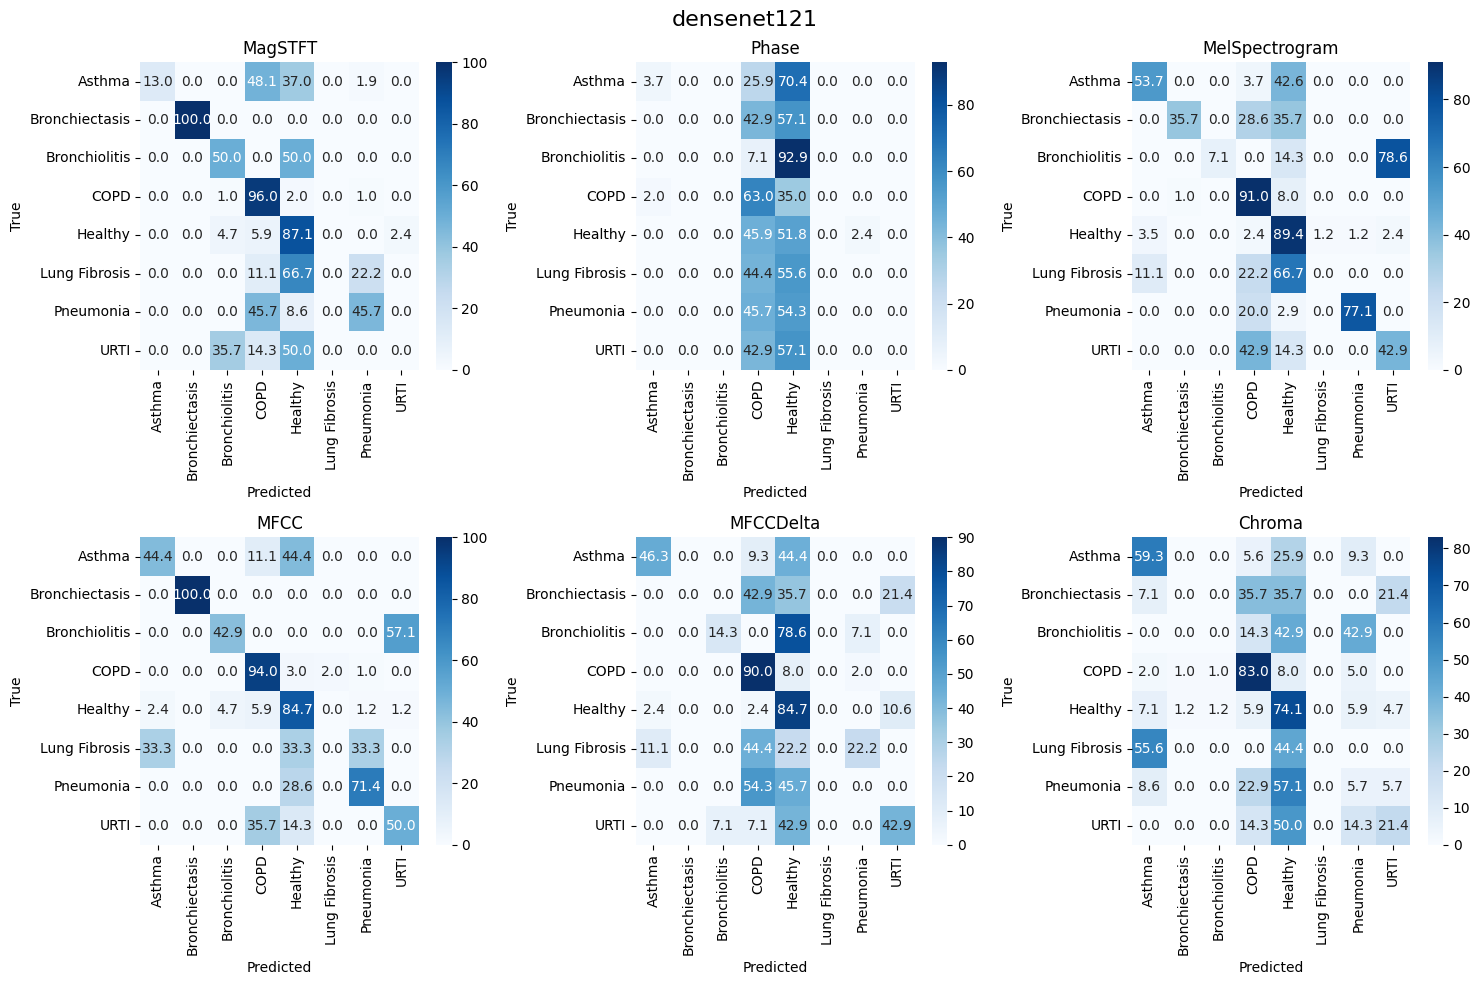

In [3]:
experiments = {
    "densenet121 - MagSTFT": "../results/densenet121-classes=8-equalizer-sample_limit=1000-MagSTFT_results.csv",
    "densenet121 - Phase": "../results/densenet121-classes=8-equalizer-sample_limit=1000-Phase_results.csv",
    "densenet121 - MelSpectrogram": "../results/densenet121-classes=8-equalizer-sample_limit=1000-MelSpectrogram_results.csv",
    "densenet121 - MFCC": "../results/densenet121-classes=8-equalizer-sample_limit=1000-MFCC_results.csv",
    "densenet121 - MFCCDelta": "../results/densenet121-classes=8-equalizer-sample_limit=1000-MFCCDelta_results.csv",
    "densenet121 - Chroma": "../results/densenet121-classes=8-equalizer-sample_limit=1000-Chroma_results.csv",
}

show_results(experiments)

A análise dos resultados mostra diferenças bem claras entre as representações utilizadas.

De forma geral, as melhores features foram MagSTFT, MelSpectrogram e MFCC, indicando que essas representações preservam informações importantes relacionadas ao conteúdo espectral dos sinais respiratórios.

Por outro lado, as features de fase da STFT e Chroma apresentaram desempenho inferior, com predições quase aleatórias. As matrizes de confusão sugerem que os modelos treinados com essas representações tendem a concentrar suas previsões nas classes mais frequentes do conjunto de dados, como COPD ou Healthy, resultando em baixa capacidade de generalização para as demais classes.

Além disso, observa-se que o MFCC apresentou os melhores resultados gerais, especialmente quando utilizado com a arquitetura DenseNet121.

Dado o desempenho superior da DenseNet121 considerando a acurácia, e tendo o melhor modelo até agora, optamos por utilizá-la nas próximas análises.

## Features Combinadas

Após avaliar cada feature individualmente, foram realizados experimentos combinando diferentes representações do sinal. O objetivo é verificar se informações complementares podem ser exploradas simultaneamente pela rede neural, permitindo uma melhor caracterização dos sons pulmonares.

### Resultados com a STFT

Nesta etapa foram avaliadas três representações derivadas da STFT:

- Magnitude da STFT (MagSTFT)
- Magnitude e fase combinadas (MagSTFT + Phase)
- Partes real e imaginária da STFT (RealSTFT + ImagSTFT)

Queremos investigar se informações adicionais da representação complexa da STFT podem contribuir para o desempenho do modelo.

======== Classification Reports ========


========== Confusion Matrices ==========


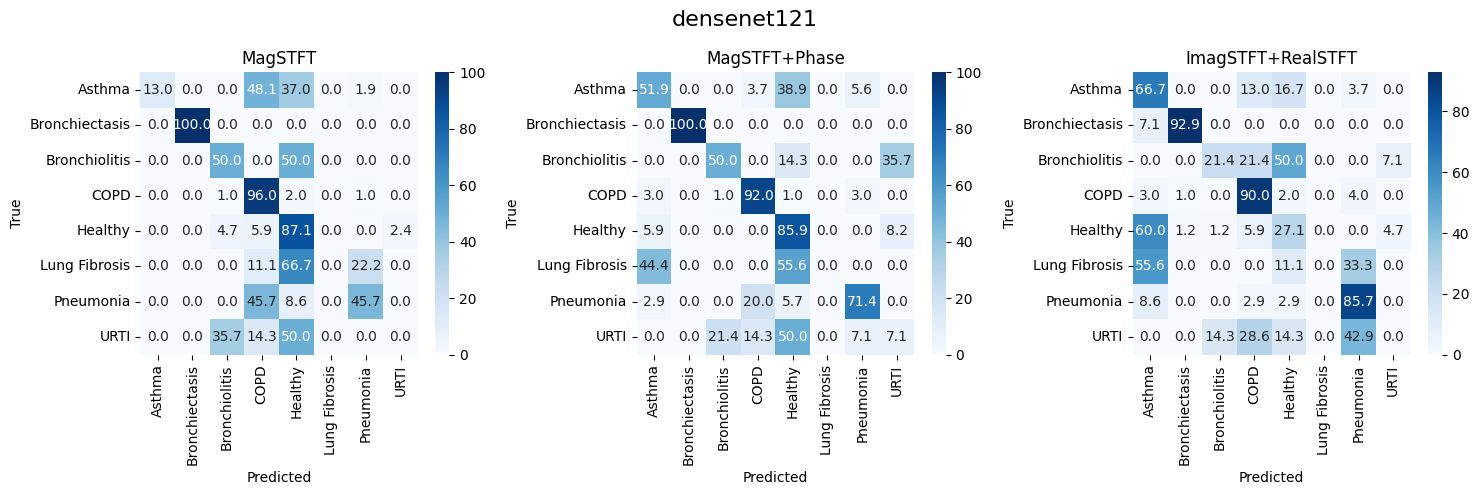

In [4]:
experiments = {
    "densenet121 - MagSTFT": "../results/densenet121-classes=8-equalizer-sample_limit=1000-MagSTFT_results.csv",
    "densenet121 - MagSTFT+Phase": "../results/densenet121-classes=8-equalizer-sample_limit=1000-Stack_MagSTFT_Phase_results.csv",
    "densenet121 - ImagSTFT+RealSTFT": "../results/densenet121-classes=8-equalizer-sample_limit=1000-Stack_ImagSTFT_RealSTFT_results.csv",
}

show_results(experiments)

| Métrica  | MagSTFT |                                       MagSTFT+Phase | ImagSTFT+RealSTFT |
| -------- | ------: | --------------------------------------------------: | ----------------: |
| F1 Macro |   <span style="background-color:#B8860B">0.471</span> | <span style="background-color:#2E8B22">0.578</span> |             0.454 |
| F1 Micro |   <span style="background-color:#B8860B">0.658</span> | <span style="background-color:#2E8B22">0.738</span> |             0.600 |


Os resultados mostram que a combinação entre magnitude e fase da STFT apresentou desempenho superior ao uso apenas da magnitude.

Embora a fase isoladamente tenha apresentado resultados limitados nos experimentos anteriores, sua combinação com a magnitude parece fornecer informações complementares que podem auxiliar o processo de classificação.

Por outro lado, a representação baseada nas componentes real e imaginária da STFT apresentou desempenho inferior, sugerindo que a magnitude da STFT contém informações mais relevantes para caracterizar o sinal e sua doença respiratória.

### Resultados com MelSpectrogram + MFCC + Chroma

Nesta etapa foi avaliada a combinação de três representações amplamente utilizadas em tarefas de processamento de áudio:

- MelSpectrogram
- MFCC
- Chroma

Essa abordagem pode ser encontrada em vários trabalhos envolvendo este tipo de classificação, resultando, geralmente, em melhorarias significativas do desempenho do modelo. As três features foram empilhadas em 3 canais de entrada, o que permitiu simular uma imagem RGB.

======== Classification Reports ========


========== Confusion Matrices ==========


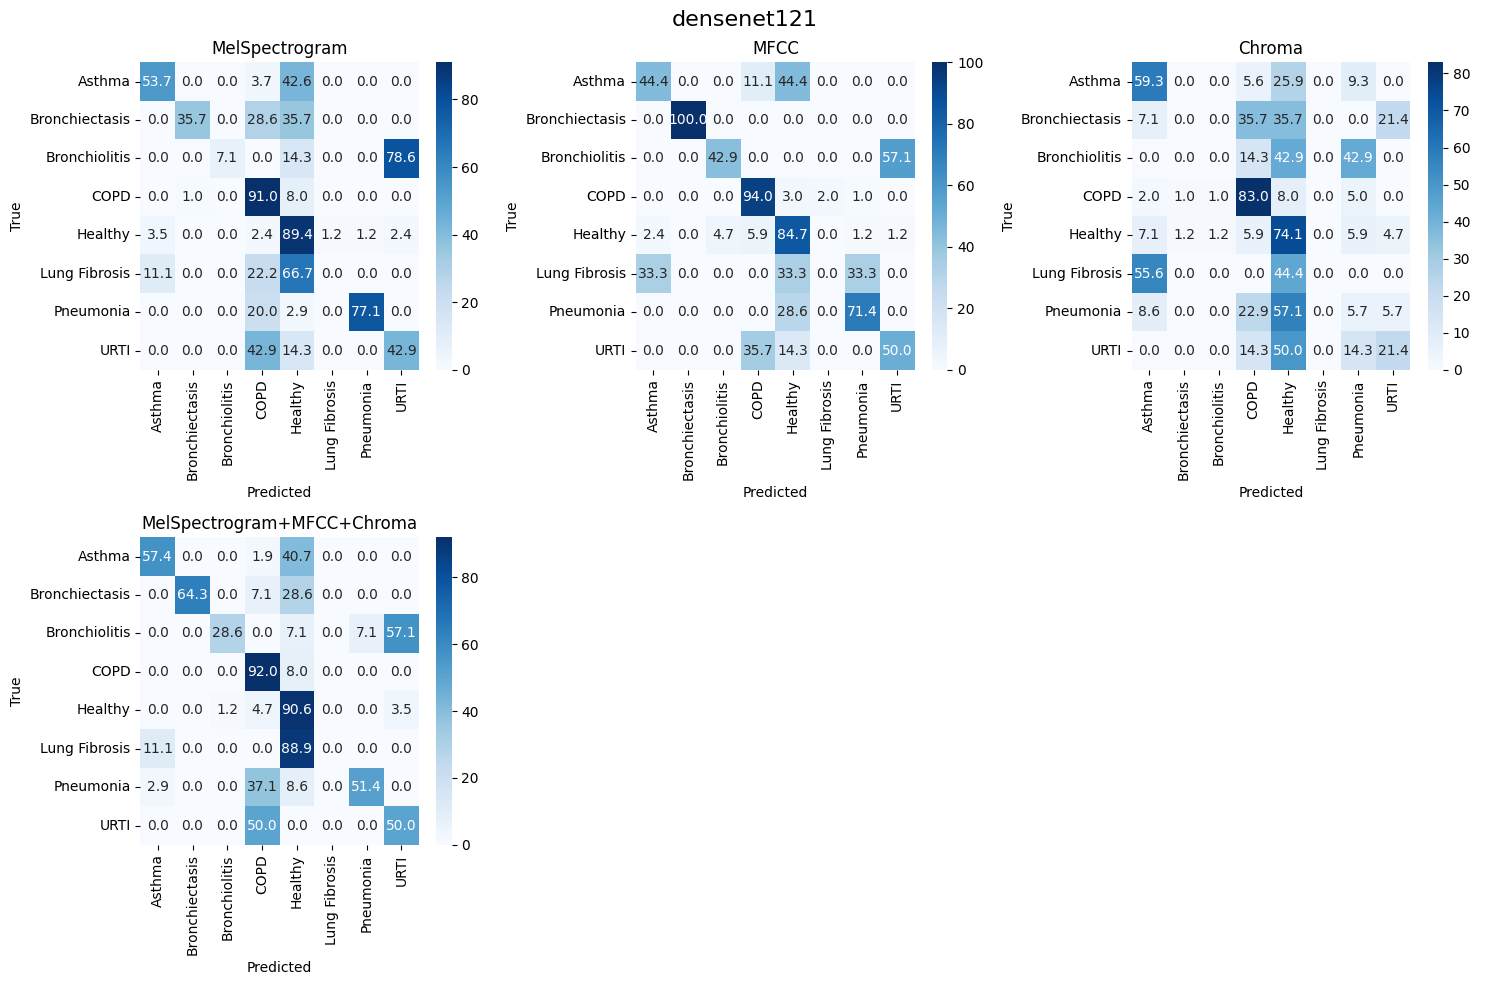

In [5]:
experiments = {
    "densenet121 - MelSpectrogram": "../results/densenet121-classes=8-equalizer-sample_limit=1000-MelSpectrogram_results.csv",
    "densenet121 - MFCC": "../results/densenet121-classes=8-equalizer-sample_limit=1000-MFCC_results.csv",
    "densenet121 - Chroma": "../results/densenet121-classes=8-equalizer-sample_limit=1000-Chroma_results.csv",
    "densenet121 - MelSpectrogram+MFCC+Chroma": "../results/densenet121-classes=8-equalizer-sample_limit=1000-Stack_MelSpectrogram_MFCC_Chroma_results.csv",
}

show_results(experiments)

| Métrica  | MelSpectrogram |                                                MFCC | Chroma | MelSpectrogram+MFCC+Chroma |
| -------- | -------------: | --------------------------------------------------: | -----: | -------------------------: |
| F1 Macro |          0.513 | <span style="background-color:#2E8B22">0.617</span> |  0.289 |                      <span style="background-color:#B8860B">0.576</span> |
| F1 Micro |          0.723 | <span style="background-color:#2E8B22">0.745</span> |  0.563 |                      <span style="background-color:#B8860B">0.732</span> |

Os resultados mostram que a combinação das três features produziu resultados superiores ao uso isolado do MelSpectrogram e do Chroma.

No entanto, o desempenho ainda permaneceu abaixo daquele obtido utilizando apenas os MFCCs, que continuaram apresentando os melhores resultados entre as representações avaliadas.

Uma possível explicação é que a inclusão de features menos informativas pode introduzir ruído adicional, dificultando a extração dos padrões mais relevantes pelo modelo.

## Transfer Learning

Por fim, aproveitando a imagem de 3 canais gerada pelo stack das features MelSpectrogram, MFCC e Chroma, foi avaliado o impacto do uso de transfer learning na tarefa de classificação, utilizando a rede DenseNet121 pré-treinada no conjunto ImageNet.

A hipótese é que os pesos previamente aprendidos em grandes bases de imagens possam fornecer uma melhor inicialização para a rede, facilitando o aprendizado mesmo em um conjunto de dados relativamente pequeno. São comparados os resultados obtidos com treinamento do zero e com pesos pré-treinados.

======== Classification Reports ========


========== Confusion Matrices ==========


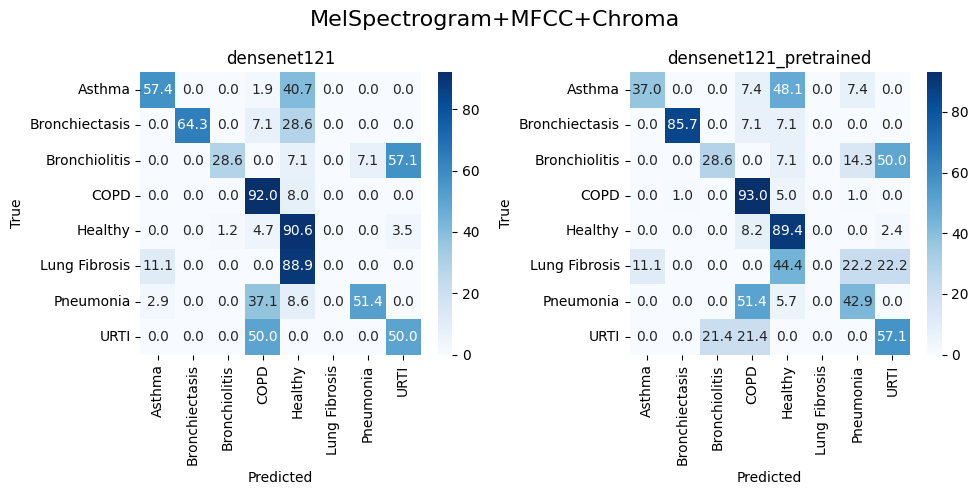

In [6]:
experiments = {
    "densenet121 - MelSpectrogram+MFCC+Chroma": "../results/densenet121-classes=8-equalizer-sample_limit=1000-Stack_MelSpectrogram_MFCC_Chroma_results.csv",
    "densenet121_pretrained - MelSpectrogram+MFCC+Chroma": "../results/densenet121-classes=8-equalizer-sample_limit=1000-pretrained-Stack_MelSpectrogram_MFCC_Chroma_results.csv",
}

show_results(experiments)

| Modelo | Feature | F1 Macro | F1 Micro |
|---------|---------|---------:|---------:|
| DenseNet121 | MelSpectrogram + MFCC + Chroma | <span style="background-color:#228B22">0.576</span> | <span style="background-color:#228B22">0.732</span> |
| DenseNet121 (Pré-treinado) | MelSpectrogram + MFCC + Chroma | 0.547 | 0.702 |

Os resultados indicam que o uso de pesos pré-treinados não trouxe ganhos de desempenho neste experimento. Tanto o F1 Macro quanto o F1 Micro apresentaram valores inferiores quando comparados ao modelo treinado do zero.

Uma possível explicação é que os pesos pré-treinados foram obtidos a partir de imagens naturais, que possuem características bastante diferentes das representações espectrais utilizadas neste trabalho. Além disso, para utilizar os pesos ImageNet, é necessário ter um cuidado com a normalização da imagem, transformação que não foi realizada duarante nossos experimentos. Dessa forma, o conhecimento previamente aprendido pela rede pode não ser diretamente transferível para a tarefa de classificação de sons respiratórios.

Apesar disso, o resultado não descarta o uso de transfer learning em outros cenários, especialmente com conjuntos de dados maiores, com maior data augmentation ou modelos pré-treinados em tarefas mais próximas do domínio de áudio.

## Visualizações Extras

In [7]:
def generate_plots(experiments: dict):
    """
    Show the classification report and confusion matrix for each experiment.
    Args:
        experiments (dict): Dictionary with the experiment name as key and the path to the CSV file as value.
    """
    classification_reports = {}
    confusion_matrices = {}

    for experiment_name, csv_path in experiments.items():
        df = pd.read_csv(csv_path)
        if "target" not in df.columns or "pred" not in df.columns:
            continue
        y_true = df["target"].astype(int).to_numpy()
        y_pred = df["pred"].astype(int).to_numpy()

        class_names = [c.replace("prob_", "") for c in df.columns if c.startswith("prob_")]

        # Get the classification report
        report = get_classification_report(y_true, y_pred, class_names)
        classification_reports[experiment_name] = report

        # Get the confusion matrix
        cm = skm.confusion_matrix(y_true, y_pred, labels=list(range(len(class_names))))
        model_name, feature_name = experiment_name.split(" - ")
        confusion_matrices[model_name, feature_name] = cm

    rows = []
    for exp_name, df in classification_reports.items():
        model, feature = exp_name.split(" - ")
        rows.append({
            "model": model,
            "feature": feature,
            "f1_macro": df.loc["macro avg", "f1-score"],
            "f1_micro": df.loc["accuracy", "f1-score"]
        })

    summary_df = pd.DataFrame(rows)
    plt.figure(figsize=(10,5))

    sns.barplot(
        data=summary_df,
        x="feature",
        y="f1_macro",
        hue="model",
    )
    # put a line indicating the best macro f1-score globally
    best_macro_f1 = summary_df["f1_macro"].max()
    plt.axhline(y=best_macro_f1, color="red", linestyle="--", label=f"Best Macro F1-score: {best_macro_f1:.3f}")

    plt.ylabel("Macro F1-score")
    plt.xlabel("Feature")
    plt.title("Comparação entre diferentes Arquiteturas e Features (Macro F1-score)")
    plt.legend(title="Modelo")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10,5))
    sns.barplot(
        data=summary_df,
        x="feature",
        y="f1_micro",
        hue="model",
    )

    best_micro_f1 = summary_df["f1_micro"].max()
    plt.axhline(y=best_micro_f1, color="red", linestyle="--", label=f"Best Micro F1-score: {best_micro_f1:.3f}")

    plt.ylabel("Micro F1-score (Accuracy)")
    plt.xlabel("Feature")
    plt.title("Comparação entre diferentes Arquiteturas e Features (Micro F1-score)")
    plt.legend(title="Modelo")
    plt.tight_layout()
    plt.show()

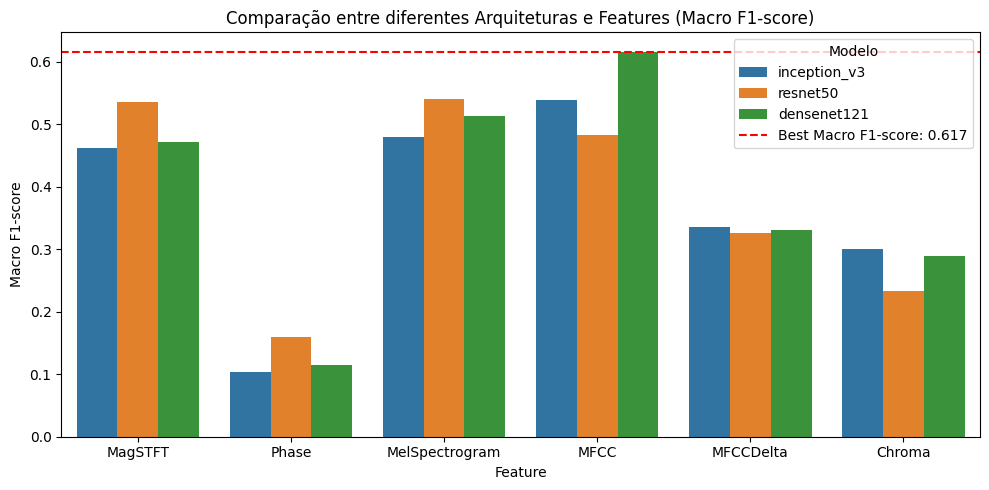

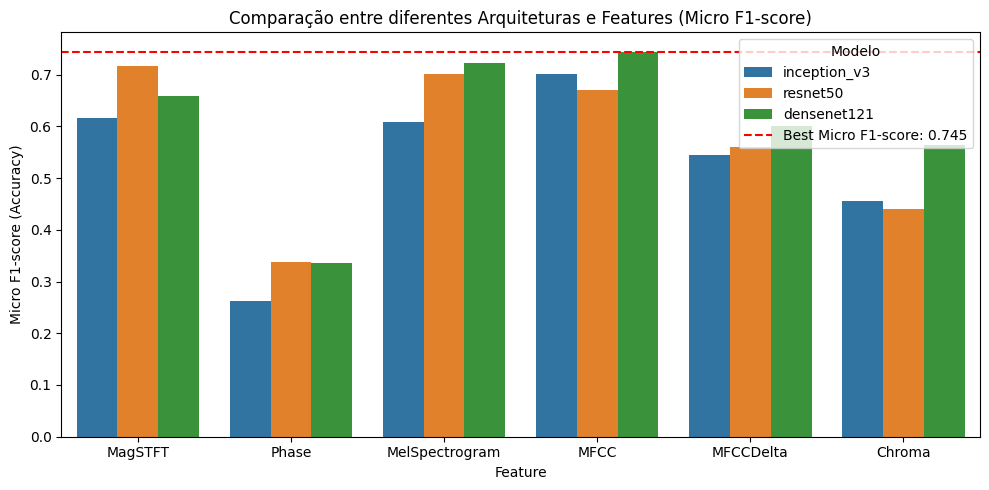

In [8]:
experiments = {
    "inception_v3 - MagSTFT": "../results/inception_v3-classes=8-equalizer-sample_limit=1000-MagSTFT_results.csv",
    "inception_v3 - Phase": "../results/inception_v3-classes=8-equalizer-sample_limit=1000-Phase_results.csv",
    "inception_v3 - MelSpectrogram": "../results/inception_v3-classes=8-equalizer-sample_limit=1000-MelSpectrogram_results.csv",
    "inception_v3 - MFCC": "../results/inception_v3-classes=8-equalizer-sample_limit=1000-MFCC_results.csv",
    "inception_v3 - MFCCDelta": "../results/inception_v3-classes=8-equalizer-sample_limit=1000-MFCCDelta_results.csv",
    "inception_v3 - Chroma": "../results/inception_v3-classes=8-equalizer-sample_limit=1000-Chroma_results.csv",
    "resnet50 - MagSTFT": "../results/resnet50-classes=8-equalizer-sample_limit=1000-MagSTFT_results.csv",
    "resnet50 - Phase": "../results/resnet50-classes=8-equalizer-sample_limit=1000-Phase_results.csv",
    "resnet50 - MelSpectrogram": "../results/resnet50-classes=8-equalizer-sample_limit=1000-MelSpectrogram_results.csv",
    "resnet50 - MFCC": "../results/resnet50-classes=8-equalizer-sample_limit=1000-MFCC_results.csv",
    "resnet50 - MFCCDelta": "../results/resnet50-classes=8-equalizer-sample_limit=1000-MFCCDelta_results.csv",
    "resnet50 - Chroma": "../results/resnet50-classes=8-equalizer-sample_limit=1000-Chroma_results.csv",
    "densenet121 - MagSTFT": "../results/densenet121-classes=8-equalizer-sample_limit=1000-MagSTFT_results.csv",
    "densenet121 - Phase": "../results/densenet121-classes=8-equalizer-sample_limit=1000-Phase_results.csv",
    "densenet121 - MelSpectrogram": "../results/densenet121-classes=8-equalizer-sample_limit=1000-MelSpectrogram_results.csv",
    "densenet121 - MFCC": "../results/densenet121-classes=8-equalizer-sample_limit=1000-MFCC_results.csv",
    "densenet121 - MFCCDelta": "../results/densenet121-classes=8-equalizer-sample_limit=1000-MFCCDelta_results.csv",
    "densenet121 - Chroma": "../results/densenet121-classes=8-equalizer-sample_limit=1000-Chroma_results.csv",
}
generate_plots(experiments)

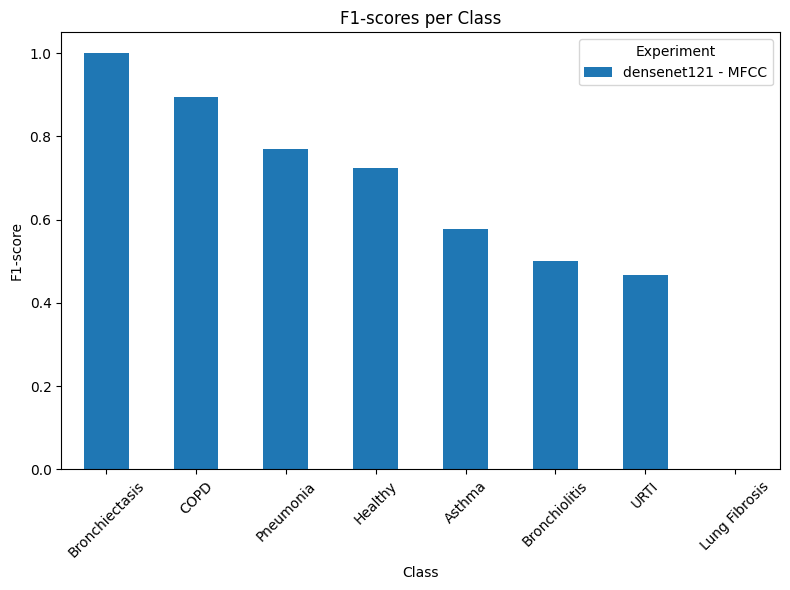

In [9]:
experiments = {
    "densenet121 - MFCC": "../results/densenet121-classes=8-equalizer-sample_limit=1000-MFCC_results.csv",
}

def plot_f1_scores_per_class(experiments: dict):
    """
    Plot the F1-scores for each class for the given experiments.
    Args:
        experiments (dict): Dictionary with the experiment name as key and the path to the CSV file as value.
    """
    f1_scores = {}
    for experiment_name, csv_path in experiments.items():
        df = pd.read_csv(csv_path)
        if "target" not in df.columns or "pred" not in df.columns:
            continue
        y_true = df["target"].astype(int).to_numpy()
        y_pred = df["pred"].astype(int).to_numpy()

        class_names = [c.replace("prob_", "") for c in df.columns if c.startswith("prob_")]

        report = get_classification_report(y_true, y_pred, class_names)
        f1_scores[experiment_name] = report["f1-score"]

    # remove macro avg and accuracy from the f1_scores dictionary
    for experiment_name in f1_scores.keys():
        f1_scores[experiment_name] = {k: v for k, v in f1_scores[experiment_name].items() if k not in ["accuracy", "macro avg", "weighted avg"]}

    f1_df = pd.DataFrame(f1_scores)
    # order by best to worst F1-score
    f1_df = f1_df.sort_values(by=list(f1_scores.keys()), ascending=False)
    f1_df.plot(kind="bar", figsize=(8, 6))
    plt.title("F1-scores per Class")
    plt.ylabel("F1-score")
    plt.xlabel("Class")
    plt.xticks(rotation=45)
    plt.legend(title="Experiment")
    plt.tight_layout()
    plt.show()

plot_f1_scores_per_class(experiments)